Notebook of <br> 
- Marmee Pandya (mpandya) <br>
- Jonas Ortner (joortner)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

%load_ext autoreload
%autoreload 2

from a04_helper import *
from a04_functions import gmm_e, gmm_m, gmm_fit

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2 Gaussian Mixture Models

## 2a) Toy data

-4380876.753061278


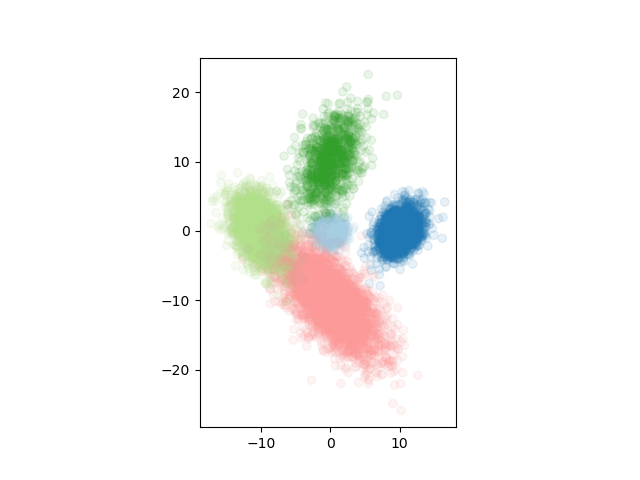

In [4]:
# Generate a toy dataset and plot it.
toy_gmm = gmm_gen(
    10000,
    [
        np.array([0, 0]),
        np.array([10, 0]),
        np.array([-10, 0]),
        np.array([0, 10]),
        np.array([0, -10]),
    ],
    np.array([0.1, 0.2, 0.25, 0.1, 0.35]),
    seed=4,
)

print(np.sum(toy_gmm["X"] ** 3))  # must be -4380876.753061278

plot_xy(toy_gmm["X"][:, 0], toy_gmm["X"][:, 1], toy_gmm["components"], alpha=0.1)
plt.savefig('images/2_toy_ppca', dpi=300, bbox_inches='tight')

In [5]:
toy_gmm["X"].shape

(10000, 2)

## 2b) K-Means

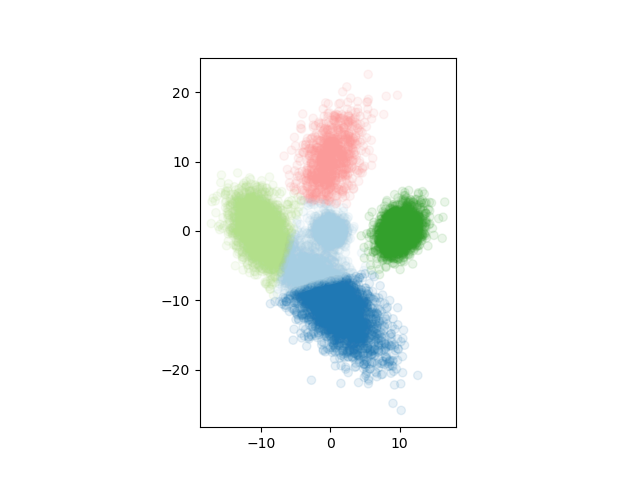

In [6]:
# Fit 5 clusters using k-means.
kmeans = KMeans(5).fit(toy_gmm["X"])
plot_xy(toy_gmm["X"][:, 0], toy_gmm["X"][:, 1], kmeans.labels_, alpha=0.1)
plt.savefig('images/2_KMeans_toy_gmm', dpi=300, bbox_inches='tight')

## 2c) Fit a GMM

In [7]:
# Implement the E step of fitting a GMM with MLE by completing gmm_e in a04_functions.py.

In [8]:
# Test your solution. This should produce:
# (array([[9.99999999e-01, 8.65221693e-10, 1.59675131e-23, 1.14015011e-41, 2.78010004e-65],
# [1.00000000e+00, 3.75078862e-12, 1.55035521e-23, 1.28102693e-34, 1.86750812e-46],
# [9.99931809e-01, 6.81161224e-05, 7.23302032e-08, 2.17176125e-09, 1.62736835e-10]]),
# array([[1.71811600e-08, 5.94620494e-18, 1.82893598e-31, 9.79455071e-50, 1.59217812e-73],
# [1.44159783e-15, 2.16285148e-27, 1.48999246e-38, 9.23362817e-50, 8.97398547e-62],
# [1.85095927e-09, 5.04355064e-14, 8.92595932e-17, 2.01005787e-18, 1.00413265e-19]]))
dummy_model = dict(
    mu=[np.array([k, k + 1]) for k in range(5)],
    Sigma=[np.array([[3, 1], [1, 2]]) / (k + 1) for k in range(5)],
    pi=np.array([0.1, 0.25, 0.15, 0.2, 0.3]),
)
gmm_e(toy_gmm["X"][:3,], dummy_model, return_P=True)

(array([[9.99999999e-01, 8.65221693e-10, 1.59675131e-23, 1.14015011e-41,
         2.78010004e-65],
        [1.00000000e+00, 3.75078862e-12, 1.55035521e-23, 1.28102693e-34,
         1.86750812e-46],
        [9.99931809e-01, 6.81161224e-05, 7.23302032e-08, 2.17176125e-09,
         1.62736835e-10]]),
 array([[1.71811600e-08, 5.94620494e-18, 1.82893598e-31, 9.79455071e-50,
         1.59217812e-73],
        [1.44159783e-15, 2.16285148e-27, 1.48999246e-38, 9.23362817e-50,
         8.97398547e-62],
        [1.85095927e-09, 5.04355064e-14, 8.92595932e-17, 2.01005787e-18,
         1.00413265e-19]]))

In [9]:
# Now, implement the M step of fitting a GMM with MLE by completing gmm_e in a04_functions.py.

In [10]:
# Test your solution. This should produce:
# {'mu': [array([ 6.70641574, -0.47971125]),
#   array([8.2353509 , 2.52134815]),
#   array([-3.0476848 , -1.70722161])],
#  'Sigma': [array([[88.09488652, 11.08635139],
#          [11.08635139,  1.39516823]]),
#   array([[45.82761873, 11.38773232],
#          [11.38773232,  6.87352224]]),
#   array([[98.6662729 , 12.41671355],
#          [12.41671355,  1.56258842]])],
#  'pi': array([0.13333333, 0.53333333, 0.33333333])}
gmm_m(toy_gmm["X"][:3,], np.array([[0.1, 0.2, 0.7], [0.3, 0.4, 0.3], [0.0, 1.0, 0.0]]))

{'mu': array([[ 6.70641574, -0.47971125],
        [ 8.2353509 ,  2.52134815],
        [-3.0476848 , -1.70722161]]),
 'Sigma': array([[[88.09488652, 11.08635139],
         [11.08635139,  1.39516823]],
 
        [[45.82761873, 11.38773232],
         [11.38773232,  6.87352224]],
 
        [[98.6662729 , 12.41671355],
         [12.41671355,  1.56258842]]]),
 'pi': array([0.13333333, 0.53333333, 0.33333333])}

## 2d+2e) Experiment with GMMs for the toy data

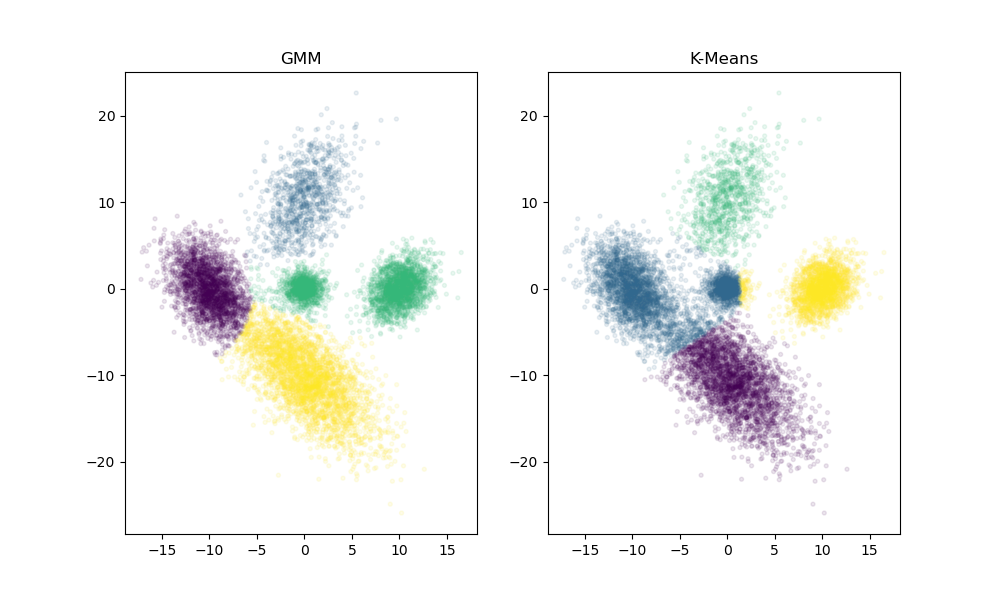

In [11]:
# Fit on toy data and color each point by most likely component. Also try fitting with 4
# or 6 components.
n_components = 4
toy_gmm_fit = gmm_fit(toy_gmm["X"], n_components)

mu = toy_gmm_fit['mu']
Sigma = toy_gmm_fit['Sigma']
pi = toy_gmm_fit['pi']

W = gmm_e(toy_gmm["X"], toy_gmm_fit)
cluster_labels = np.argmax(W, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

axes[0].set_title('GMM')
axes[0].scatter(toy_gmm["X"][:, 0],
                toy_gmm["X"][:, 1],
                c=cluster_labels,
                s=8, alpha=0.1)
# Kmeans
kmeans = KMeans(n_components).fit(toy_gmm["X"])
axes[1].set_title('K-Means')
axes[1].scatter(toy_gmm["X"][:, 0],
                toy_gmm["X"][:, 1],
                c=kmeans.labels_,
                s=8, alpha=0.1)


plt.show()
plt.savefig(f'images/{n_components}_components_plot_v1.png')

In [12]:
toy_gmm_fit

{'mu': array([[-10.05890454,  -0.01143443],
        [ -0.05319352,  10.24894316],
        [  6.23140675,  -0.02948659],
        [  0.05262685, -10.14139112]]),
 'Sigma': array([[[ 4.05254604, -2.3754577 ],
         [-2.3754577 ,  7.46617118]],
 
        [[ 5.4685951 ,  3.65771368],
         [ 3.65771368, 13.10737982]],
 
        [[28.10656618,  0.98292033],
         [ 0.98292033,  2.76897182]],
 
        [[13.12744617, -9.44523344],
         [-9.44523344, 15.68224926]]]),
 'pi': array([0.24049833, 0.09798413, 0.31676301, 0.34475453])}

In [13]:
toy_gmm['X'].shape

(10000, 2)

## 2f) Discover the Secret (optional)

In [14]:
# Load the secret data.
X = np.loadtxt("data/secret_gmm.csv", delimiter=",")